# Cloze
This notebook contains the results of the robustness study.

In [ ]:
import pandas as pd
import os

import sys
sys.path.append("..")
from src.Eval import aggregated_results_llm, results_to_dataframe, get_iobs_from_data, parse_filename
from src.Utils import read_jsonlines, read_IOB_file

output_dir = "../output/llm"
results_postcut = aggregated_results_llm(os.path.join(output_dir, "reddit+shsyt_cloze", "postcutoff_"))
results_seen = aggregated_results_llm(os.path.join(output_dir, "reddit+shsyt_cloze", "fmtcorrect_"))
results_unseen = aggregated_results_llm(os.path.join(output_dir, "reddit+shsyt_cloze", "fmtfailed_"))


../../output/llm/reddit+shsyt_cloze/postcutoff_/gpt-4o-mini/dataset1_35shot_tfidf.jsonl


2024-12-05 17:37:22 root INFO: Imported 533 predictions for 533 true examples


../../output/llm/reddit+shsyt_cloze/postcutoff_/gpt-4o-mini/dataset2_35shot_tfidf.jsonl


2024-12-05 17:37:23 root INFO: Imported 534 predictions for 534 true examples


../../output/llm/reddit+shsyt_cloze/fmtcorrect_/gpt-4o-mini/dataset1_35shot_tfidf.jsonl


...

2024-12-05 17:37:23 root INFO: Imported 534 predictions for 534 true examples


../../output/llm/reddit+shsyt_cloze/fmtfailed_/gpt-4o-mini/dataset1_35shot_tfidf.jsonl


2024-12-05 17:37:23 root INFO: Imported 533 predictions for 533 true examples


../../output/llm/reddit+shsyt_cloze/fmtfailed_/gpt-4o-mini/dataset2_35shot_tfidf.jsonl


2024-12-05 17:37:24 root INFO: Imported 534 predictions for 534 true examples


In [5]:
results_to_dataframe(results_seen)


Value                                         \
Schema                     strict                                          
Entity Type               overall                                          
Metric                   f1_macro  f1_micro precision_macro recall_macro   
Model       Sampling k                                                     
gpt-4o-mini tfidf    35  0.878696  0.877109        0.880208     0.877758   

                                                                       \
Schema                                                                  
Entity Type                Artist                                       
Metric                         f1 precision    recall missed spurious   
Model       Sampling k                                                  
gpt-4o-mini tfidf    35  0.863151   0.88047  0.846501   51.5     27.5   

                                   ...                                     \
Schema                             ... ent_type                             
Entity Type                        ...   Artist                             
Metric                  incorrect  ...   recall missed spurious incorrect   
Model       Sampling k             ...                                      
gpt-4o-mini tfidf    35      44.5  ...  0.90641   51.5     27.5       7.0   

                                                                       \
Schema                                                                  
Entity Type                   WoA                                       
Metric                         f1 precision    recall missed spurious   
Model       Sampling k                                                  
gpt-4o-mini tfidf    35  0.942311  0.927242  0.957886   16.5     32.5   

                                   
Schema                             
Entity Type                        
Metric                  incorrect  
Model       Sampling k             
gpt-4o-mini tfidf    35       4.0  

[1 rows x 48 columns]

# Analysis

### Parse preds

In [ ]:
model = "gpt-4o-mini"
k = 35
sampling = "tfidf"
data_path = f"../data/dataset/reddit+shsyt_cloze/{model}"
template_path = "../data/dataset/reddit+shsyt_cloze/data_template.parquet"
output_path = f"../output/llm/reddit+shsyt_cloze"
outputs = os.listdir(data_path)

results = {}

for dirname in outputs:
    group, perturbation = dirname.split("_")

    if not results.get(perturbation):
        results[perturbation] = {}

    _path = os.path.join(data_path, dirname)

    titles = []
    performers = []
    texts = []
    tags = []
    pred_tags = []

    for dataset in os.listdir(_path):
        _texts, _tags = read_IOB_file(os.path.join(_path, dataset, "test.IOB"))
        texts += _texts
        tags += _tags

        __path = os.path.join(output_path, dirname, model)
        for pred_file in [f for f in os.listdir(__path) if dataset in f]:
            _, pred_k, pred_sampling = parse_filename(pred_file)
            if pred_k == k and pred_sampling == sampling:
                pred_path = os.path.join(__path, pred_file)
                pred_data = read_jsonlines(pred_path)
                true_iobs, pred_iobs = get_iobs_from_data(pred_data)
                pred_tags += pred_iobs
   
        titles += [d.get("titles") for d in pred_data]
        performers += [d.get("performers") for d in pred_data]

    results[perturbation]['_'.join((group, "titles"))] = titles
    results[perturbation]['_'.join((group, "performers"))] = performers
    results[perturbation]['_'.join((group, "TEXT"))] = [list(a) for a in texts]
    results[perturbation]['_'.join((group, "IOB"))] = [list(a) for a in tags]
    results[perturbation]['_'.join((group, "IOB-pred" ))] = pred_tags

_data1 = pd.read_parquet(template_path).reset_index()
_data1.columns = pd.MultiIndex.from_tuples([('', '', col) for col in _data1.columns])

_data2 = pd.DataFrame.from_dict({(i, j): results[i][j] 
                             for i in results.keys() 
                             for j in results[i].keys()},
                            orient='index').T
_data2.columns = pd.MultiIndex.from_tuples([(t[0], t[1].split("_")[0], t[1].split("_")[1]) for t in _data2.columns], 
                                      names=['Perturbation', 'Group', 'Value'])

data = pd.concat([_data1, _data2], axis=1)


In [11]:
import importlib.util
from src.Eval_Utils import Evaluator
from pathlib import Path

eval_scheme = "strict"

def eval_pair(true_iobs, pred_iobs):
    if len(true_iobs) == len(pred_iobs):
        evaluator = Evaluator([true_iobs], [pred_iobs], ["Artist", "WoA"])
        result = evaluator.evaluate()
        overall, by_cls = result[0]["strict"], result[1]
        return overall, by_cls
    return None

for perturbation in data.columns.get_level_values(0).unique():
    for group in data.columns.get_level_values(1).unique():
        if group != '':
            series = data.apply(lambda row: eval_pair(
                    row[(perturbation, group, "IOB")], row[(perturbation, group, "IOB-pred")]), axis=1)
            data[(perturbation, group, "metrics_overall")] = series.apply(lambda x: x[0] if x else None)
            for cls in ["Artist", "WoA"]:
                for outcome in ["incorrect", "missed", "spurious"]:
                    data[(perturbation, group, f"{cls}_{outcome}")] = series.apply(lambda x: x[1][cls][eval_scheme][outcome] if x else None)


2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Imported 1 predictions for 1 true examples
2024-12-05 17:39:38 root INFO: Importe

## Robust Contexts

In [12]:
col = ('','fmtcorrect', 'WoA_incorrect')

def mask_has_metric(data, col):
    return data[col] > 0

e=data.loc[mask_has_metric(data, col), [('','fmtcorrect', "TEXT"), ('','fmtcorrect', "IOB"), 
                                        ('','fmtcorrect', "IOB-pred")]].iloc[0]
e

  fmtcorrect  TEXT        [i, aint, no, miracle, worker, music, clip, -,...
              IOB         [B-WoA, I-WoA, I-WoA, I-WoA, I-WoA, O, O, O, B...
              IOB-pred           [O, O, O, B-WoA, I-WoA, O, O, O, B-Artist]
Name: 17, dtype: object

# Performance per Group: 
### Bar Plot: x-Axis: Seen, Unseen, Post-Cutoff, y-Axis: Incorrect, Spurious, Missed


2024-12-05 17:40:22 matplotlib.backends.backend_pdf DEBUG: Assigning font /F1 = '/data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
2024-12-05 17:40:22 matplotlib.backends.backend_pdf DEBUG: Embedding font /data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
2024-12-05 17:40:22 matplotlib.backends.backend_pdf DEBUG: Writing TrueType font.


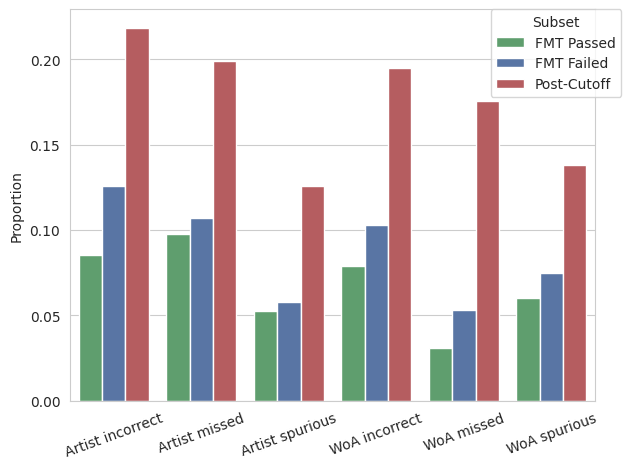

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['WoA_spurious', 'WoA_incorrect', 'WoA_missed', 'Artist_spurious', 'Artist_incorrect', 'Artist_missed']

plot_data = data[""]
plot_data = plot_data.loc[:, plot_data.columns.get_level_values(1).isin(metrics)]

plot_data = plot_data.stack(level=0).reset_index(
    level=0, drop=True).reset_index().groupby(by="index").sum().reset_index().rename(
        columns={"index": "Subset"}
    )
plot_data.Subset = plot_data.Subset.str.replace(
    "fmtfailed", "FMT Failed").str.replace(
        "fmtcorrect", "FMT Passed").str.replace("postcutoff", "Post-Cutoff")

plot_data = pd.melt(plot_data, 
                    id_vars="Subset", 
                    value_vars=metrics, 
                    var_name="Metric", 
                    value_name="Proportion").sort_values(by=["Subset", "Metric"])
status_order = ["FMT Passed", "FMT Failed", "Post-Cutoff"]
plot_data['Subset'] = pd.Categorical(plot_data['Subset'], categories=status_order, ordered=True)
plot_data.Metric = plot_data.Metric.str.replace("_", " ")
plot_data.Proportion = plot_data.Proportion / len(data)

palette = sns.color_palette(["#55a868", "#4c72b0", "#c44e52"])
sns.set_style("whitegrid")
sns.barplot(data=plot_data, x='Metric', y="Proportion", hue='Subset', palette=palette)
plt.xlabel("")
plt.xticks(rotation=20)
plt.title("")
plt.legend(title="Subset", loc='upper right', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.savefig(f"../../figures/error_analysis.pdf")
plt.show()



# Further questions
- exact eval scheme vs. strict
- context length per Origin (YouTube Reddit Context)
    - scatter plot
    - Correlation
- contexts
    - robust (no mistakes in neither of the groups)
    - 


In [15]:
mask_robust = data.loc[:,data.columns.get_level_values(1).isin(metrics)].T.sum() == 0

data[mask_robust].sample(1)


\
                                                 
      index                id  set_id   Origin   
279  105304  5483_HjYgAfQ-hPM  5483.0  YouTube   

                                                        \
                                                         
                                                  TEXT   
279  [molly, hatchet, -, charlie, daniels, free, bi...   

                                                                            \
                                                                             
                                                   IOB subset        yt_id   
279  [B-Artist, I-Artist, O, B-Artist, I-Artist, B-...      5  HjYgAfQ-hPM   

                        ...      perturb2                          \
                        ...     fmtfailed                           
    has_WoA has_Artist  ... WoA_incorrect WoA_missed WoA_spurious   
279    True       True  ...           1.0        0.0          0.0   

                                                                         \
                                            fmtcorrect                    
                                       metrics_overall Artist_incorrect   
279  {'correct': 2, 'incorrect': 2, 'partial': 0, '...              1.0   

                                                                         
                                                                         
    Artist_missed Artist_spurious WoA_incorrect WoA_missed WoA_spurious  
279           0.0             0.0           1.0        0.0          0.0  

[1 rows x 122 columns]

2024-12-05 17:41:03 matplotlib.colorbar DEBUG: locator: <matplotlib.ticker.AutoLocator object at 0x7f9619f401d0>
/tmp/ipykernel_1495940/4165893037.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .9, 1])
2024-12-05 17:41:03 matplotlib.backends.backend_pdf DEBUG: Assigning font /F1 = '/data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
2024-12-05 17:41:04 matplotlib.backends.backend_pdf DEBUG: Embedding font /data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
2024-12-05 17:41:04 matplotlib.backends.backend_pdf DEBUG: Writing TrueType font.


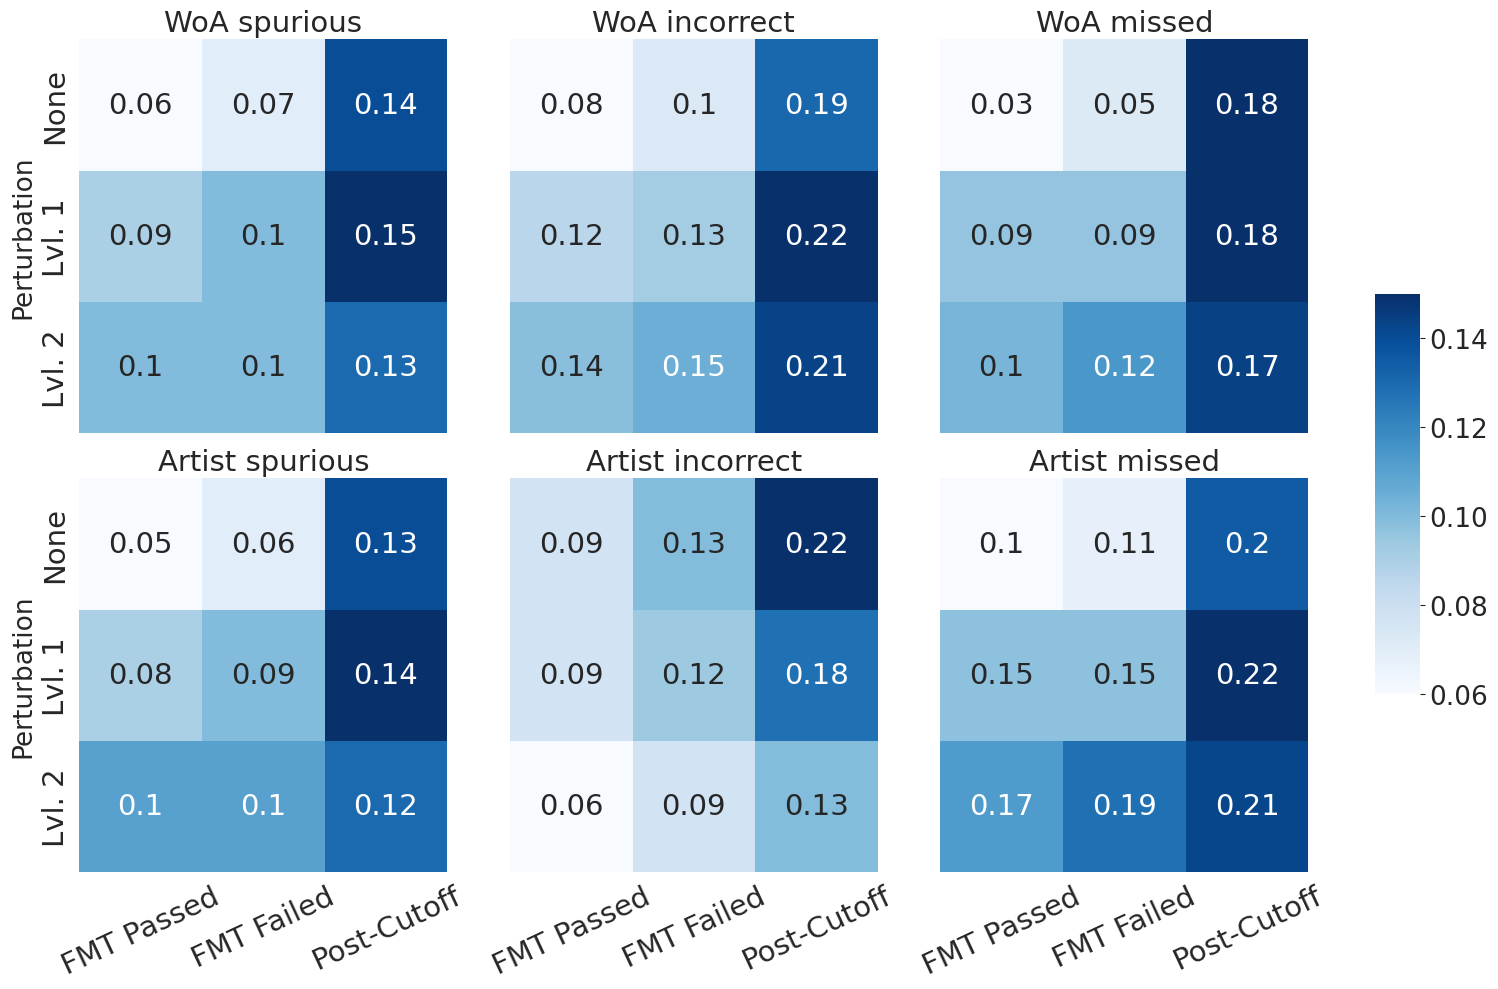

In [ ]:
def get_metric_sums(df, metric):
    metric_df = df.xs(metric, axis=1, level=2)
    metric_sum = metric_df.sum()
    metric_sum_df = metric_sum.unstack(level=1)
    metric_sum_df = metric_sum_df[["fmtcorrect", "fmtfailed", "postcutoff"]]
    metric_sum_df.columns = ["FMT Passed", "FMT Failed", "Post-Cutoff"]
    metric_sum_df.index = [["None", "Lvl. 1", "Lvl. 2"]]
    return metric_sum_df

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
cbar_ax = fig.add_axes([.92, .3, .03, .4])

N = data[("", "", "TEXT_template")].apply(str).nunique()

for i, metric in enumerate(metrics):
    plot_data = get_metric_sums(data, metric).apply(lambda x: round(x/N, 2))
    ax = axs[i // 3, i % 3]
    sns.heatmap(plot_data, annot=True, fmt="g", cmap="Blues", ax=ax, 
                cbar=(i == 0), cbar_ax=None if i else cbar_ax, annot_kws={"size": 21})  # Increase annotation font size
    
    ax.set_title(metric.replace("_", " "), fontsize=21)
    
    if i % 3 == 0:
        ax.set_ylabel("Perturbation", fontsize=19)
    else:
        ax.set_ylabel("")
    # Increase font size of x-ticks and y-ticks
    ax.tick_params(axis='x', labelsize=21, rotation=25)  # X-axis tick font size
    ax.tick_params(axis='y', labelsize=21)  # Y-axis tick font size


# Set colorbar label size
cbar_ax.tick_params(labelsize=19)

plt.tight_layout(rect=[0, 0, .9, 1])
plt.savefig("../figures/heatmap_groups_perturb.pdf")
plt.show()


In [18]:
def get_mask_for_metric(metric: str):
    return data.loc[:,data.columns.get_level_values(2).str.contains(metric)].T.sum() == 3

def get_unrobust_cloze_texts(data: pd.DataFrame, metric: str, nsample: int):
    data = data[get_mask_for_metric(metric)].sample(frac=1)
    texts = data[('', '', 'TEXT_template')].apply(lambda x: ' '.join(x)).to_list()
    origins = data[('', '', 'Origin')].to_list()
    return texts[:nsample], origins[:nsample]

get_unrobust_cloze_texts(data, "WoA_spurious", 10)


(['songs [WoA] by [Artist] with those kinds of guitar riffs .',
  'songs similar to : [WoA] ( [Artist] remix ) [ feat . [Artist] ]',
  'songs with themes of being unable to settle ? ( ex : [Artist] [WoA] , [Artist] [WoA] )',
  'music like [Artist] and [Artist]',
  'suggest something similar to " [Artist] - [WoA] " ?',
  'looking for other songs / artists with a sound similar to this [Artist] / [Artist] remix . tried lots of other [Artist] stuff but not very keen . also artists like [Artist] . . . . electronic / dance type music with a bit of a live vibe .',
  'music similar to the [Artist] - [WoA] ?',
  'atlanta [YEAR] : [Artist] and friends : [WoA]',
  'looking for something similar to the [WoA] [YEAR] soundtrack',
  'recommend me some songs similar to the [WoA] [Artist] remix by [Artist] ?'],
 ['Reddit',
  'Reddit',
  'Reddit',
  'Reddit',
  'Reddit',
  'Reddit',
  'Reddit',
  'YouTube',
  'Reddit',
  'Reddit'])

In [19]:
get_unrobust_cloze_texts(data, "WoA_missed", 10)


(['any recommendations for songs like the [WoA] album by [Artist] ?',
  '[WoA] ( [Artist] cover )',
  '[WoA] - [Artist] ~ similar songs ?',
  '[Artist] [WoA] . wmv',
  '[Artist] [WoA] ( [WoA] )',
  '[Artist] - - [WoA]',
  '03 [Artist] - [WoA]',
  '[Artist] – [WoA] ( argo ) [YEAR]',
  '[Artist] / [Artist] [ [WoA] ] live audio cover',
  'any similar songs like " [WoA] by [Artist] " or " [WoA] also by [Artist] " or " [WoA] [Artist] " rock songs with clean vocals ?'],
 ['Reddit',
  'YouTube',
  'Reddit',
  'YouTube',
  'YouTube',
  'YouTube',
  'YouTube',
  'YouTube',
  'YouTube',
  'Reddit'])

In [20]:
get_unrobust_cloze_texts(data, "WoA_incorrect", 10)


(['im looking for songs that are exactly like this [Artist] - [WoA]',
  'looking for similar music to the [WoA] ost .',
  'songs that are derivatives of [Artist] [WoA] ?',
  '12 [WoA] ( [Artist] )',
  'really enjoyed the album [WoA] by [Artist] . anything similar ?',
  'songs like [WoA] [WoA] !',
  '[WoA] - [Artist] ( acoustic cover )',
  '[WoA] - [Artist] - [YEAR]',
  'music with similar theme as [WoA] - [Artist] on the incapacity to take care of someone ( even if one would like to ) . any genre ok !',
  '[WoA] [Artist] [YEAR] sanat jaana rinne'],
 ['Reddit',
  'Reddit',
  'Reddit',
  'YouTube',
  'Reddit',
  'Reddit',
  'Reddit',
  'YouTube',
  'Reddit',
  'YouTube'])

In [21]:
get_unrobust_cloze_texts(data, "Artist_missed", 10)


(['pretty music in 3 / 4 like " [WoA] " and [Artist] " [WoA] "',
  'looking for an album or ep in cassette tape format of synth / electronic music with no lyrics and sounds somewhat similar to [Artist] music ?',
  '❤• * • . [WoA] - [Artist] * • . ❤¸',
  '[WoA] ~ [Artist] [ by [Artist] ]',
  '[Artist] & [Artist] - [WoA] ( live ) - hd',
  '[Artist] - [WoA] [WoA] [ bbc radio [YEAR] - [YEAR] ]',
  '♥ [WoA] ( [Artist] )',
  '[Artist] / [WoA]',
  '[WoA] . . . - [Artist]',
  'music like this ? ( [Artist] : [WoA] , specific songs )'],
 ['Reddit',
  'Reddit',
  'YouTube',
  'YouTube',
  'YouTube',
  'YouTube',
  'YouTube',
  'YouTube',
  'YouTube',
  'Reddit'])

In [22]:
get_unrobust_cloze_texts(data, "Artist_incorrect", 10)


(['[WoA] - [Artist] ( [Artist] cover )',
  'for fans of 70s psychedelia and progressive rock . think [Artist] meets [Artist] , and at the end [Artist] crashes the party .',
  'looking for songs like " [WoA] " by [Artist]',
  '[Artist] – [WoA] ( argo ) [YEAR]',
  'looking for the similar beat / tune / flow ( [Artist] - [WoA] )',
  'what should my wife listen to if she likes [Artist] , [Artist] , [Artist] and [Artist] ?',
  'im looking for songs similar to [Artist] - [WoA]',
  '[Artist] & [Artist] - [WoA] [YEAR]',
  '[WoA] / [WoA] - [Artist]',
  'suggest me something similar to [WoA] by [Artist]'],
 ['YouTube',
  'Reddit',
  'Reddit',
  'YouTube',
  'Reddit',
  'Reddit',
  'Reddit',
  'YouTube',
  'Reddit',
  'Reddit'])

In [23]:
get_unrobust_cloze_texts(data, "Artist_spurious", 10000)


(['any bands like [Artist] era [Artist] ?',
  '[WoA] - [Artist] , [Artist] , [Artist] , & [Artist] - [WoA]',
  'looking for songs similar to [WoA] by [Artist]',
  'looking for more music that sounds like modern spaghetti western ( like this track from [WoA] and [WoA] )',
  'music similar to [WoA] ( netflix series )',
  'anything similar to australian rapper [Artist]',
  'music like : [WoA] by [Artist] .',
  'looking for similar tracks to [Artist] & [Artist] - [WoA]',
  'hip - hop / funk / psychedelic music like [Artist]',
  '[WoA] music clip - [Artist]',
  'more like [Artist] [ groove , thrash metal ]',
  'trolls [WoA] comic - con clip | trolls',
  '[WoA] [Artist] [YEAR]',
  '[Artist] [Artist] and [Artist] - [WoA]',
  'similar to [WoA] ( remix ) by [Artist] or [WoA] / [WoA] / [WoA] - [Artist] , or [WoA] - [Artist] / [Artist]',
  'songs similar to [WoA] by [Artist] please ?',
  '[Artist] & [Artist] - [WoA] ( live )',
  '[Artist] - [WoA] . [Artist] & [Artist] )',
  '[Artist] , but shes s

2024-12-05 17:41:38 matplotlib.backends.backend_pdf DEBUG: Assigning font /F1 = '/data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'


2024-12-05 17:41:38 matplotlib.backends.backend_pdf DEBUG: Embedding font /data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
2024-12-05 17:41:38 matplotlib.backends.backend_pdf DEBUG: Writing TrueType font.


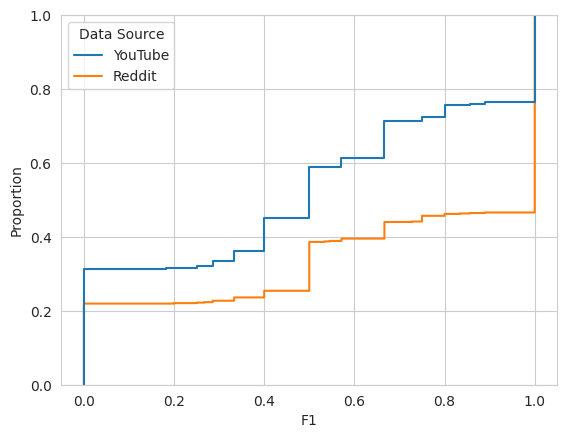

In [25]:
data[("", "", "f1")] = data[('', 'postcutoff','metrics_overall')].apply(lambda x: x["f1"] if x else None)

sns.ecdfplot(data, x=("", "", "f1"), hue=("", "", "Origin"), legend="Data Source")
legend = plt.gca().get_legend()
legend.set_title("Data Source")
plt.xlabel("F1")
plt.savefig("../../figures/f1_distributions.pdf")
plt.show()


# Correlation Outer Context with F1

In [26]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

y = data[("", "postcutoff", "metrics_overall")].apply(lambda x: x["f1"] if x else None)
x = data.loc[~y.isna(),("", "", "nO_tags")]
y = y.dropna()

print(f"Pearson r {pearsonr(x,y)}")
print(f"Spearman r {spearmanr(x,y)}")


Pearson r PearsonRResult(statistic=0.10991559336308541, pvalue=0.0003302723317639422)
Spearman r SignificanceResult(statistic=0.1330470719340158, pvalue=1.3485073756502874e-05)


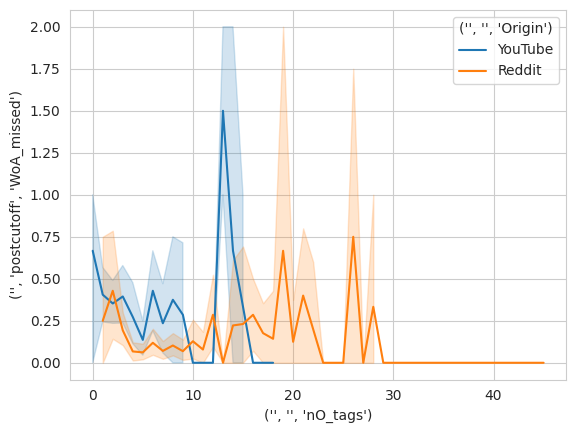

In [27]:
xcol = ("", "", "nO_tags")
ycol = ("postcutoff", "WoA_spurious")
huecol = ("", "", "Origin")

sns.lineplot(data=data, x=("", "", "nO_tags"), y=("", "postcutoff", "WoA_missed"), hue=("", "", "Origin"))
plt.show()


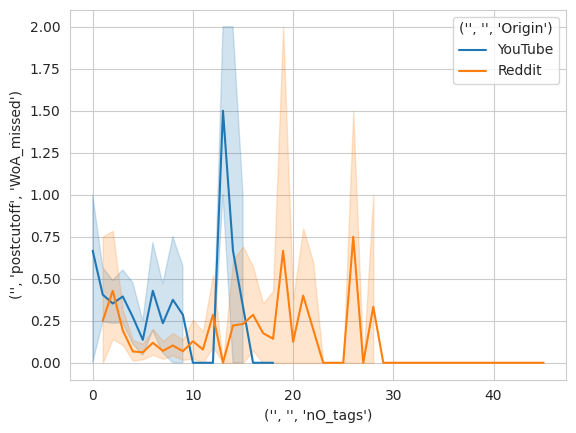

In [28]:
xcol = ("", "nO_tags")
ycol = ("postcutoff", "WoA_incorrect")
huecol = ("", "Origin")

sns.lineplot(data=data, x=("", "", "nO_tags"), y=("", "postcutoff", "WoA_missed"), hue=("", "", "Origin"))
plt.show()


# Clusters

2024-12-05 17:42:10 matplotlib.backends.backend_pdf DEBUG: Assigning font /F1 = '/data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
2024-12-05 17:42:10 matplotlib.backends.backend_pdf DEBUG: Embedding font /data/miniconda3/envs/ytuncoverllm/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
2024-12-05 17:42:10 matplotlib.backends.backend_pdf DEBUG: Writing TrueType font.


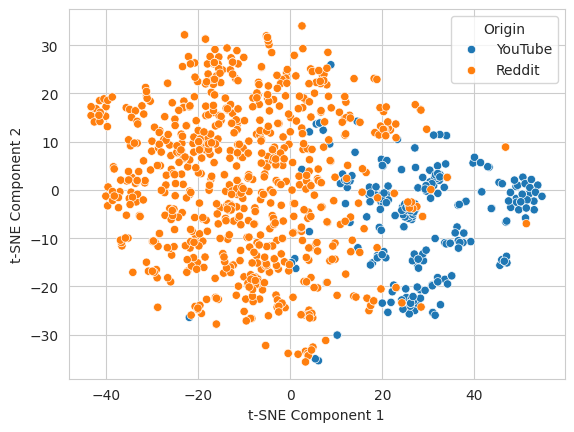

In [29]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
import numpy as np


plot_data = pd.DataFrame()




vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data[("", "", 'TEXT_template')].apply(lambda x: ' '.join(x)))

tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X.toarray())


plot_data["Origin"] = data[("", "", "Origin")]
plot_data["x"] = X_tsne[:, 0]
plot_data["y"] = X_tsne[:, 1]

sns.scatterplot(plot_data, x=X_tsne[:, 0], y=X_tsne[:, 1], hue="Origin")

# Add a color bar and labels
#plt.colorbar(scatter, label='Cluster')
#plt.title('DBSCAN Clusters in 2D Space (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.savefig("../../figures/scatter_cloze.pdf")
plt.show()

